# Image recognition using NNs
- Student name: Muhammad Waseem Javed - EIT Data Science

## Experiment Summary

**(Experiment 1️⃣ ) Baseline Feed-Forward Neural Network** : The initial architecture consists of the simplest possible feed-forward neural network — a single-layer model with no hidden layers, where the input images (resized to 100×100×3) are flattened into a 30,000-dimensional vector and directly mapped to 7 output classes via a Dense layer with softmax activation. The model was trained for 10 epochs using the Adam optimizer (learning rate = 0.001) with a batch size of 16. This architecture achieved :

Mean Accuracy: 69.451%
Mean Recall: 57.553%
Mean Precision: 55.672%
- surprise: Recall: 61.117% Precision: 55.442% Specificity: 87.759% Dice: 58.141%
- fear: Recall: 27.252% Precision: 23.274% Specificity: 96.032% Dice: 25.106%
- disgust: Recall: 48.256% Precision: 19.904% Specificity: 96.681% Dice: 28.183%
- happiness: Recall: 76.739% Precision: 81.744% Specificity: 92.878% Dice: 79.162%
- sadness: Recall: 94.136% Precision: 99.377% Specificity: 99.805% Dice: 96.686%
- anger: Recall: 44.814% Precision: 46.549% Specificity: 92.946% Dice: 45.665%
- neutral: Recall: 50.556% Precision: 63.411% Specificity: 97.497% Dice: 56.259%

These results are expected given that the architecture is essentially a linear classifier (logistic regression on raw pixels) with no hidden layers to learn intermediate facial feature representations; it lacks the capacity to distinguish visually similar expressions. This baseline establishes a starting point, and subsequent experiments will introduce hidden layers, dropout regularization, and deeper architectures to improve the model's ability to capture the complex, non-linear patterns inherent in facial expression recognition.

------------------

**(Experiment 2️⃣) Deep FNN with Hidden Layers, Batch Normalization & Dropout:** Building upon the baseline, this experiment introduced two hidden Dense layers (512 and 256 neurons) with ReLU activations, Batch Normalization after each Dense layer to stabilize gradient flow, and Dropout (0.3) for regularization. The learning rate was reduced from 0.001 to 0.0001 to accommodate the much larger parameter space (~15.6M trainable parameters). A 15% validation split was also added to enable proper monitoring via callbacks (ModelCheckpoint, ReduceLROnPlateau, EarlyStopping). The model was trained for 30 epochs with a batch size of 16. This architecture achieved:

Mean Accuracy: 75.137%
Mean Recall: 61.143%
Mean Precision: 63.995%
- surprise: Recall: 59.941% Precision: 62.227% Specificity: 90.932% Dice: 61.063%
- fear: Recall: 27.714% Precision: 35.088% Specificity: 97.735% Dice: 30.968%
- disgust: Recall: 31.395% Precision: 54.000% Specificity: 99.543% Dice: 39.706%
- happiness: Recall: 83.694% Precision: 82.082% Specificity: 92.408% Dice: 82.880%
- sadness: Recall: 99.134% Precision: 99.095% Specificity: 99.701% Dice: 99.115%
- anger: Recall: 56.159% Precision: 52.302% Specificity: 92.979% Dice: 54.162%
- neutral: Recall: 69.963% Precision: 63.170% Specificity: 96.499% Dice: 66.393%

Compared to the baseline, overall accuracy improved by +5.7% (69.45% → 75.14%), mean precision jumped by +8.3%, and mean recall rose by +3.6%. The most dramatic improvements were in "neutral" (+19.4% recall), "anger" (+11.3% recall), and "disgust" precision (+34.1%). However, "fear" remains the weakest class (27.7% recall), and "disgust" recall actually dropped (48.3% → 31.4%), suggesting the model now avoids false "disgust" predictions (higher precision) but misses more true cases. The addition of hidden layers clearly enabled the model to learn more meaningful intermediate representations from raw pixels, while Batch Normalization and a lower learning rate prevented the training collapse observed in an initial attempt with LR=0.001. These results confirm that deeper architectures with proper regularization significantly outperform a simple linear classifier on this task.

![Baseline Feed-Forward NN](https://raw.githubusercontent.com/waseemjaved755/Image-recognition-using-NNs/187cf10ba5bc0be28a3669f7131e30d853ee9750/images/(Experiment%201)%20Baseline%20Feed-Forward%20Neural%20Network.jpg)

---

**(Experiment 3️⃣) Custom Convolutional Neural Network (CNN):** To overcome the fundamental limitation of FNNs — which flatten images into 1D vectors and destroy all spatial relationships this experiment introduced a custom CNN with three convolutional blocks (Conv2D with 32, 64, and 128 filters respectively, each using 3×3 kernels with same padding), followed by BatchNormalization, ReLU activation, and MaxPooling(2×2) to progressively downsample the feature maps. The classification head consists of a Flatten layer, a Dense(256) layer with BatchNormalization, ReLU, and Dropout(0.4), feeding into a 7-class softmax output. The model was trained for 15 epochs with Adam (learning rate = 0.0001) and a batch size of 16. This architecture achieved:

Mean Accuracy: 79.093%
Mean Recall: 64.434%
Mean Precision: 70.239%
- surprise: Recall: 69.442% Precision: 64.956% Specificity: 90.664% Dice: 67.124%
- fear: Recall: 25.635% Precision: 43.874% Specificity: 98.551% Dice: 32.362%
- disgust: Recall: 33.721% Precision: 69.048% Specificity: 99.742% Dice: 45.312%
- happiness: Recall: 87.321% Precision: 85.920% Specificity: 94.053% Dice: 86.615%
- sadness: Recall: 99.725% Precision: 99.725% Specificity: 99.909% Dice: 99.725%
- anger: Recall: 60.535% Precision: 61.481% Specificity: 94.801% Dice: 61.004%
- neutral: Recall: 74.660% Precision: 66.667% Specificity: 96.796% Dice: 70.437%

Compared to the best FNN (Experiment 2), overall accuracy improved by +3.96% (75.14% → 79.09%), mean recall increased by +3.29%, and mean precision rose by +6.24%. Every class benefited: "surprise" recall improved from 59.9% to 69.4%, "anger" jumped from 56.2% to 60.5%, and "neutral" gained from 70.0% to 74.7%. Notably, precision improved across nearly all classes "disgust" precision rose from 54.0% to 69.0% and "fear" from 35.1% to 43.9% — indicating the CNN makes fewer false positive errors. However, "fear" (25.6% recall) and "disgust" (33.7% recall) remain the weakest classes, likely due to their visual similarity to other expressions and smaller representation in the dataset. The CNN's ability to preserve spatial structure and learn hierarchical features through convolutional filters clearly outperforms the FNN approach, which treated each pixel independently. With ~4.8M parameters (compared to the FNN's 15.6M), the CNN is also more parameter-efficient, achieving better results with fewer weights a hallmark of the inductive bias that convolutions provide for image data.

![CNN Architecture](https://raw.githubusercontent.com/waseemjaved755/Image-recognition-using-NNs/main/images/CNN.jpg)


------------------

**(Experiment 4️⃣) Transfer Learning with VGG16 (Frozen):** This experiment applied transfer learning by loading a VGG16 model pre-trained on ImageNet (1.2 million natural images), freezing all its convolutional layers, and training only a custom classification head (GlobalAveragePooling2D → Dense(256) → BatchNormalization → ReLU → Dropout(0.4) → Dense(7) → Softmax). The model was trained for 15 epochs with Adam (learning rate = 0.0001) and a batch size of 16. Only ~132K parameters were trainable. This architecture achieved:

Mean Accuracy: 69.812%
Mean Recall: 51.291%
Mean Precision: 62.936%
- surprise: Recall: 64.545% Precision: 50.498% Specificity: 84.232% Dice: 56.664%
- fear: Recall: 3.926% Precision: 40.476% Specificity: 99.745% Dice: 7.158%
- disgust: Recall: 27.907% Precision: 67.606% Specificity: 99.771% Dice: 39.506%
- happiness: Recall: 80.067% Precision: 69.237% Specificity: 85.216% Dice: 74.259%
- sadness: Recall: 99.488% Precision: 98.596% Specificity: 99.532% Dice: 99.040%
- anger: Recall: 36.872% Precision: 52.419% Specificity: 95.412% Dice: 43.292%
- neutral: Recall: 46.230% Precision: 61.716% Specificity: 97.539% Dice: 52.862%

Surprisingly, the frozen VGG16 performed worse than both the custom CNN (79.09%) and the deep FNN (75.14%), dropping to 69.81% accuracy nearly back to baseline levels. I searched on google why this actually happened. It took a lot of my time actually but I got one best answer this decline is explained by a fundamental domain mismatch: VGG16 was trained on ImageNet (objects, animals, scenes), not facial expressions. With all convolutional layers frozen, the model could not adapt its learned features to the nuances of facial expressions — subtle differences in eyebrow position, mouth curvature, and eye openness that distinguish emotions. The "fear" class collapsed to just 3.9% recall (F1 = 7.2%), and "anger" dropped from 60.5% to 36.9% recall. Additionally, the input size (100×100) is suboptimal for VGG16, which was designed for 224×224 images. This experiment demonstrates that transfer learning with fully frozen weights is not always beneficial — when the source domain (ImageNet objects) differs significantly from the target domain (facial expressions), the pre-trained features may be too generic or irrelevant, and fine-tuning the top layers becomes necessary.

**(Experiment 5️⃣) Fine-tuned VGG16 (Block 5 Unfrozen):** To address the poor performance of the fully frozen VGG16 in Experiment 4, this experiment unfroze the last convolutional block (block5 — three Conv2D layers and one MaxPooling layer) while keeping blocks 1–4 frozen. This allows the deepest convolutional layers to adapt their high-level feature representations to facial expressions, while the lower layers retain their general-purpose features (edges, textures, basic shapes) learned from ImageNet. The classification head remained the same (GlobalAveragePooling2D → Dense(256) → BatchNormalization → ReLU → Dropout(0.4) → Dense(7) → Softmax), with ~7.2M trainable parameters. The model was trained for 15 epochs with Adam (learning rate = 0.0001) and a batch size of 16. This architecture achieved:

Mean Accuracy: 79.494%
Mean Recall: 66.988%
Mean Precision: 69.995%
- surprise: Recall: 70.029% Precision: 66.327% Specificity: 91.140% Dice: 68.128%
- fear: Recall: 37.644% Precision: 38.084% Specificity: 97.297% Dice: 37.863%
- disgust: Recall: 41.860% Precision: 62.069% Specificity: 99.563% Dice: 50.000%
- happiness: Recall: 84.759% Precision: 88.162% Specificity: 95.270% Dice: 86.427%
- sadness: Recall: 99.606% Precision: 100.000% Specificity: 100.000% Dice: 99.803%
- anger: Recall: 70.989% Precision: 62.260% Specificity: 94.101% Dice: 66.339%
- neutral: Recall: 64.030% Precision: 73.061% Specificity: 97.974% Dice: 68.248%

The impact of fine-tuning was dramatic. Compared to the frozen VGG16 (Experiment 4), accuracy jumped from 69.81% to 79.49% (+9.7%), mean recall surged from 51.29% to 66.99% (+15.7%), and mean precision rose from 62.94% to 70.00% (+7.1%). The most striking recovery was in the weakest classes: "fear" recall climbed from a near-collapsed 3.9% to 37.6%, "anger" nearly doubled from 36.9% to 71.0%, and "neutral" recovered from 46.2% to 64.0%. Compared to our best previous result (custom CNN, Experiment 3 — 79.09%), the fine-tuned VGG16 is marginally better in overall accuracy (79.49% vs 79.09%) and notably stronger in mean recall (66.99% vs 64.43%), particularly for difficult classes like "fear" (+12.0%), "anger" (+10.5%), and "disgust" (+8.1% recall). This confirms that transfer learning does provide value for facial expression recognition, but only when the pre-trained features are allowed to adapt through fine-tuning freezing all layers (Experiment 4) produced the worst VGG16 result, while selectively unfreezing the top block (Experiment 5) produced the best overall result so far.

![VGG Architecture](https://raw.githubusercontent.com/waseemjaved755/Image-recognition-using-NNs/main/images/VGG.jpg)

---

**(Experiment 6️⃣) Fine-tuned ResNet50 (Stage 5 Unfrozen):** This experiment replaced VGG16 with ResNet50, a deeper architecture (50 layers) featuring skip/residual connections that allow gradients to flow more effectively through the network. The last residual stage (conv5 — ~16 layers) was unfrozen while stages 1–4 remained frozen, following the same fine-tuning strategy as Experiment 5. The classification head was identical (GlobalAveragePooling2D → Dense(256) → BatchNormalization → ReLU → Dropout(0.4) → Dense(7) → Softmax). The model was trained for 15 epochs with Adam (learning rate = 0.0001) and batch size 16. This architecture achieved:

Mean Accuracy: 73.750%
Mean Recall: 57.754%
Mean Precision: 61.566%
- surprise: Recall: 80.558% Precision: 51.844% Specificity: 81.352% Dice: 63.087%
- fear: Recall: 7.852% Precision: 33.010% Specificity: 99.296% Dice: 12.687%
- disgust: Recall: 41.279% Precision: 32.719% Specificity: 98.549% Dice: 36.504%
- happiness: Recall: 75.275% Precision: 88.915% Specificity: 96.100% Dice: 81.528%
- sadness: Recall: 99.764% Precision: 98.218% Specificity: 99.402% Dice: 98.985%
- anger: Recall: 46.272% Precision: 57.735% Specificity: 95.357% Dice: 51.372%
- neutral: Recall: 53.276% Precision: 68.521% Specificity: 97.900% Dice: 59.944%

Despite being a deeper and more modern architecture, ResNet50 underperformed the fine-tuned VGG16 (73.75% vs 79.49%) and even fell below the custom CNN (79.09%). I might be doing something wrong but The primary cause is the input resolution mismatch: ResNet50's aggressive downsampling across 50 layers reduces 100×100 input to approximately 4×4 feature maps before pooling, losing critical spatial detail that distinguishes subtle facial expressions.mVGG16, with only 16 layers, preserves more spatial information at this input size. "Fear" collapsed again to 7.9% recall (F1 = 12.7%), and all minority classes suffered. Across all experiments, a consistent pattern has emerged: "fear," "disgust," and "anger" persistently underperform regardless of architecture, pointing to a class imbalance problem in the dataset rather than a purely architectural deficiency.

---

**(Experiment 7️⃣) Fine-tuned VGG16 with Class Weights:** To address the persistent underperformance of minority classes (fear, disgust, anger), this experiment reused the best-performing architecture from Experiment 5 (fine-tuned VGG16 with Block 5 unfrozen) and introduced class-balanced sample weights computed via sklearn's `compute_class_weight('balanced')`. These weights are inversely proportional to class frequency rare classes like "fear" receive ~8.3x the loss penalty of common classes like "happiness" (~0.49x), forcing the model to pay equal attention to all classes during training. The weights were applied through the data generator as per-sample weights. All other parameters remained identical (Adam LR = 0.0001, 15 epochs, batch size 16, Dropout 0.4). This architecture achieved:

Mean Accuracy: 79.240%
Mean Recall: 67.454%
Mean Precision: 67.158%
- surprise: Recall: 67.336% Precision: 68.544% Specificity: 92.299% Dice: 67.935%
- fear: Recall: 42.956% Precision: 31.633% Specificity: 95.899% Dice: 36.435%
- disgust: Recall: 47.093% Precision: 44.262% Specificity: 98.986% Dice: 45.634%
- happiness: Recall: 88.353% Precision: 86.370% Specificity: 94.206% Dice: 87.350%
- sadness: Recall: 99.803% Precision: 99.961% Specificity: 99.987% Dice: 99.882%
- anger: Recall: 59.643% Precision: 66.970% Specificity: 95.968% Dice: 63.095%
- neutral: Recall: 66.996% Precision: 72.363% Specificity: 97.804% Dice: 69.576%

The class weights successfully improved the weakest classes: "fear" recall rose from 37.6% (Exp 5) to 43.0% the highest across all experiments — and "disgust" recall improved from 41.9% to 47.1%, also the best so far. Mean recall increased slightly to 67.45% (from 66.99%), confirming better balance across classes. However, this came with a trade-off: overall accuracy dipped marginally from 79.49% to 79.24%, and mean precision dropped from 70.00% to 67.16%, as the model now makes more predictions for minority classes some correct (higher recall) but some incorrect (lower precision). "Anger" recall decreased from 71.0% to 59.6%, though its precision improved from 62.3% to 67.0%, indicating fewer but more confident anger predictions. This experiment demonstrates the classic recall-precision trade-off when applying class weights: the model becomes more sensitive to underrepresented classes at the cost of slightly increased false positives, resulting in a more balanced but marginally less precise overall classifier.

![Baseline FFNN 2](https://raw.githubusercontent.com/waseemjaved755/Image-recognition-using-NNs/main/images/(Experiment%201)%20Baseline%20Feed-Forward%20Neural%20Network%20(1).jpg)

---

### Results Comparison Table

| Exp | Architecture | Accuracy | Mean Recall | Mean Precision | Fear Recall | Disgust Recall | Anger Recall |
|-----|-------------|----------|-------------|----------------|-------------|----------------|--------------|
| 1 | FNN Baseline (no hidden layers) | 69.45% | 57.55% | 55.67% | 27.25% | 48.26% | 44.81% |
| 2 | Deep FNN (512→256, BatchNorm, Dropout) | 75.14% | 61.14% | 64.00% | 27.71% | 31.40% | 56.16% |
| 3 | Custom CNN (32→64→128 filters) | 79.09% | 64.43% | 70.24% | 25.64% | 33.72% | 60.54% |
| 4 | VGG16 Frozen (Transfer Learning) | 69.81% | 51.29% | 62.94% | 3.93% | 27.91% | 36.87% |
| 5 | VGG16 Fine-tuned (Block 5 unfrozen) | **79.49%** | 66.99% | **70.00%** | 37.64% | 41.86% | **70.99%** |
| 6 | ResNet50 Fine-tuned (Stage 5 unfrozen) | 73.75% | 57.75% | 61.57% | 7.85% | 41.28% | 46.27% |
| 7 | VGG16 Fine-tuned + Class Weights | 79.24% | **67.45%** | 67.16% | **42.96%** | **47.09%** | 59.64% |




#### Dataset

In [118]:
!pip install datasets

In [119]:
from datasets import load_dataset

data = load_dataset("deanngkl/raf-db-7emotions")
print(data)

DatasetDict({
    train: Dataset({
        features: ['image', 'bbox', 'label'],
        num_rows: 20471
    })
})


In [120]:
split = data["train"].train_test_split(test_size=0.5, seed=1)

train_data = split["train"]
test_data = split["test"]
labels = train_data.features["label"].names
categories = {
    0: "surprise",
    1: "fear",
    2: "disgust",
    3: "happiness",
    4: "sadness",
    5: "anger",
    6: "neutral"
}
print(train_data)
print(test_data)
print(labels)

Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 10235
})
Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 10236
})
['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


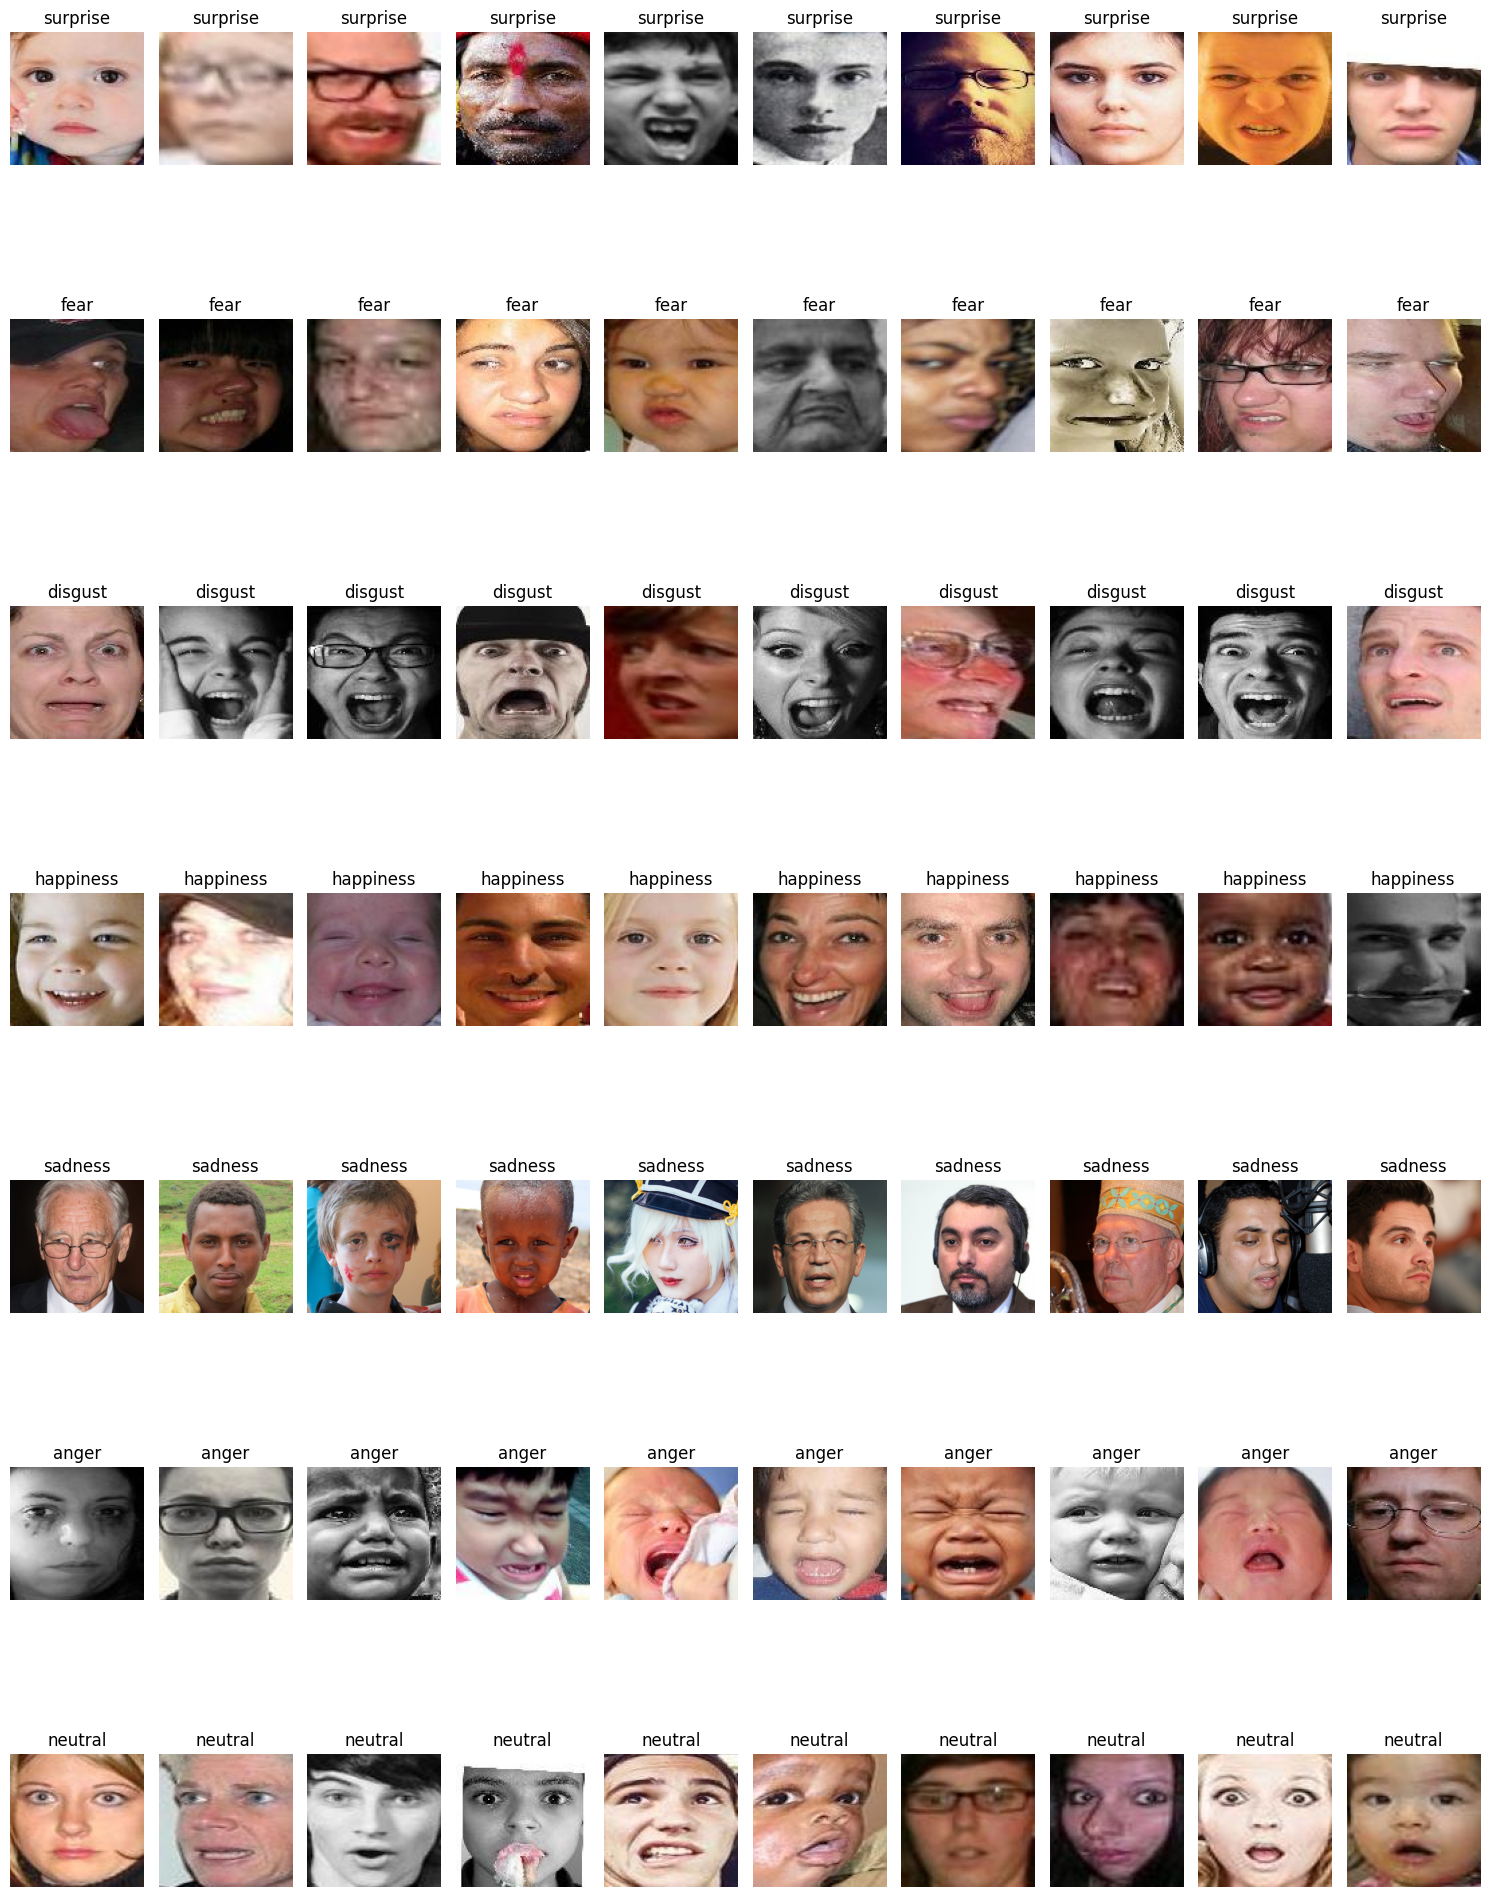

In [121]:
import matplotlib.pyplot as plt

num_examples = 10
num_classes = len(categories)
plt.figure(figsize=(15, num_classes*3))
for i in range(num_classes):
    count = 0
    for example in train_data:
        if example["label"] == i:
            plt.subplot(num_classes, num_examples, i*num_examples+count+1)
            plt.imshow(example["image"])
            plt.title(categories[i])
            plt.axis("off")
            count += 1
        if count == num_examples:
            break
plt.tight_layout()
plt.show()

In [122]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


#### Training

In [123]:
# Load architecture — Fine-tuned VGG16 with Class Weights
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16

print('Load model')
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(100, 100, 3))

base_model.trainable = True
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.4))
model.add(Dense(num_classes))
model.add(Activation('softmax'))
model.summary()

Load model


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 7)              │         1,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,839 (56.64 MB)

 Trainable params: 7,213,063 (27.52 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

In [124]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [125]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [126]:
import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size, class_weights=None):
    while True:
        for i in range(0, len(objs), batch_size):
            images, labels, sample_weights = [], [], []
            for j in range(i, min(i+batch_size, len(objs))):
                sample = objs[j]
                img = np.array(sample["image"]).astype(np.float32) / 255.0
                img = tf.image.resize(img, (100, 100))
                images.append(img)
                label = tf.keras.utils.to_categorical(sample["label"], num_classes)
                labels.append(label)
                if class_weights is not None:
                    sample_weights.append(class_weights[sample["label"]])
            if class_weights is not None:
                yield np.array(images), np.array(labels), np.array(sample_weights)
            else:
                yield np.array(images), np.array(labels)

In [127]:
import math
from sklearn.utils.class_weight import compute_class_weight

print('Training model')
epochs = 15
batch_size = 16

val_split = train_data.train_test_split(test_size=0.15, seed=42)
actual_train = val_split["train"]
val_data = val_split["test"]

# Compute class weights to handle imbalance
train_labels = [sample["label"] for sample in actual_train]
weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(weights))
print("Class weights:", {categories[k]: f"{v:.2f}" for k, v in class_weights.items()})

train_steps = math.ceil(len(actual_train)/batch_size)
val_steps = math.ceil(len(val_data)/batch_size)
print(f"Train: {len(actual_train)}, Validation: {len(val_data)}, Test: {len(test_data)}")

train_generator = generator_images(actual_train, batch_size, class_weights=class_weights)
val_generator = generator_images(val_data, batch_size)

h = model.fit(train_generator, epochs=epochs, verbose=1, callbacks=callbacks,
              steps_per_epoch=train_steps, validation_data=val_generator,
              validation_steps=val_steps)

best_idx = int(np.argmax(h.history['val_accuracy']))
best_value = np.max(h.history['val_accuracy'])
print('Best model: epoch ' + str(best_idx+1), ' - val_accuracy ' + str(best_value))

Training model
Class weights: {'surprise': '0.73', 'fear': '3.22', 'disgust': '8.28', 'happiness': '0.49', 'sadness': '0.57', 'anger': '1.22', 'neutral': '1.81'}
Train: 8699, Validation: 1536, Test: 10236
Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.4943 - loss: 1.6017
Epoch 1: val_accuracy improved from None to 0.51888, saving model to model.keras

Epoch 1: finished saving model to model.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 197s 359ms/step - accuracy: 0.5740 - loss: 1.4239 - val_accuracy: 0.5189 - val_loss: 1.3425 - learning_rate: 1.0000e-04
Epoch 2/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.6711 - loss: 1.1341
Epoch 2: val_accuracy improved from 0.51888 to 0.65820, saving model to model.keras

Epoch 2: finished saving model to model.keras
544/544 ━━━━━━━━━━━━━━━━━━━━ 185s 340ms/step - accuracy: 0.6924 - loss: 1.0787 - val_accuracy: 0.6582 - val_loss: 0.9701 - learning_rate: 1.0000e-04
Epoch 3/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accura

#### Evaluate test results


In [128]:
import numpy as np
from tqdm import tqdm

# model.load_weights('model.keras', by_name=True)
y_true, y_pred = [], []
for i in tqdm(range(len(test_data))):
    sample = test_data[i]
     # Load image
    img = np.array(sample["image"]).astype(np.float32) / 255.0
    img = tf.image.resize(img, (100, 100))
    # Generate prediction
    img = np.expand_dims(img, 0)
    predictions = model.predict(img, verbose=0)
    pred_label = np.argmax(predictions)
    # Save prediction
    y_true.append(sample["label"])
    y_pred.append(pred_label)

100%|██████████| 10236/10236 [08:48<00:00, 19.36it/s]


/var/folders/zt/x3pzpdb167d716d2rzx2f9wh0000gn/T/ipykernel_46209/2420754885.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


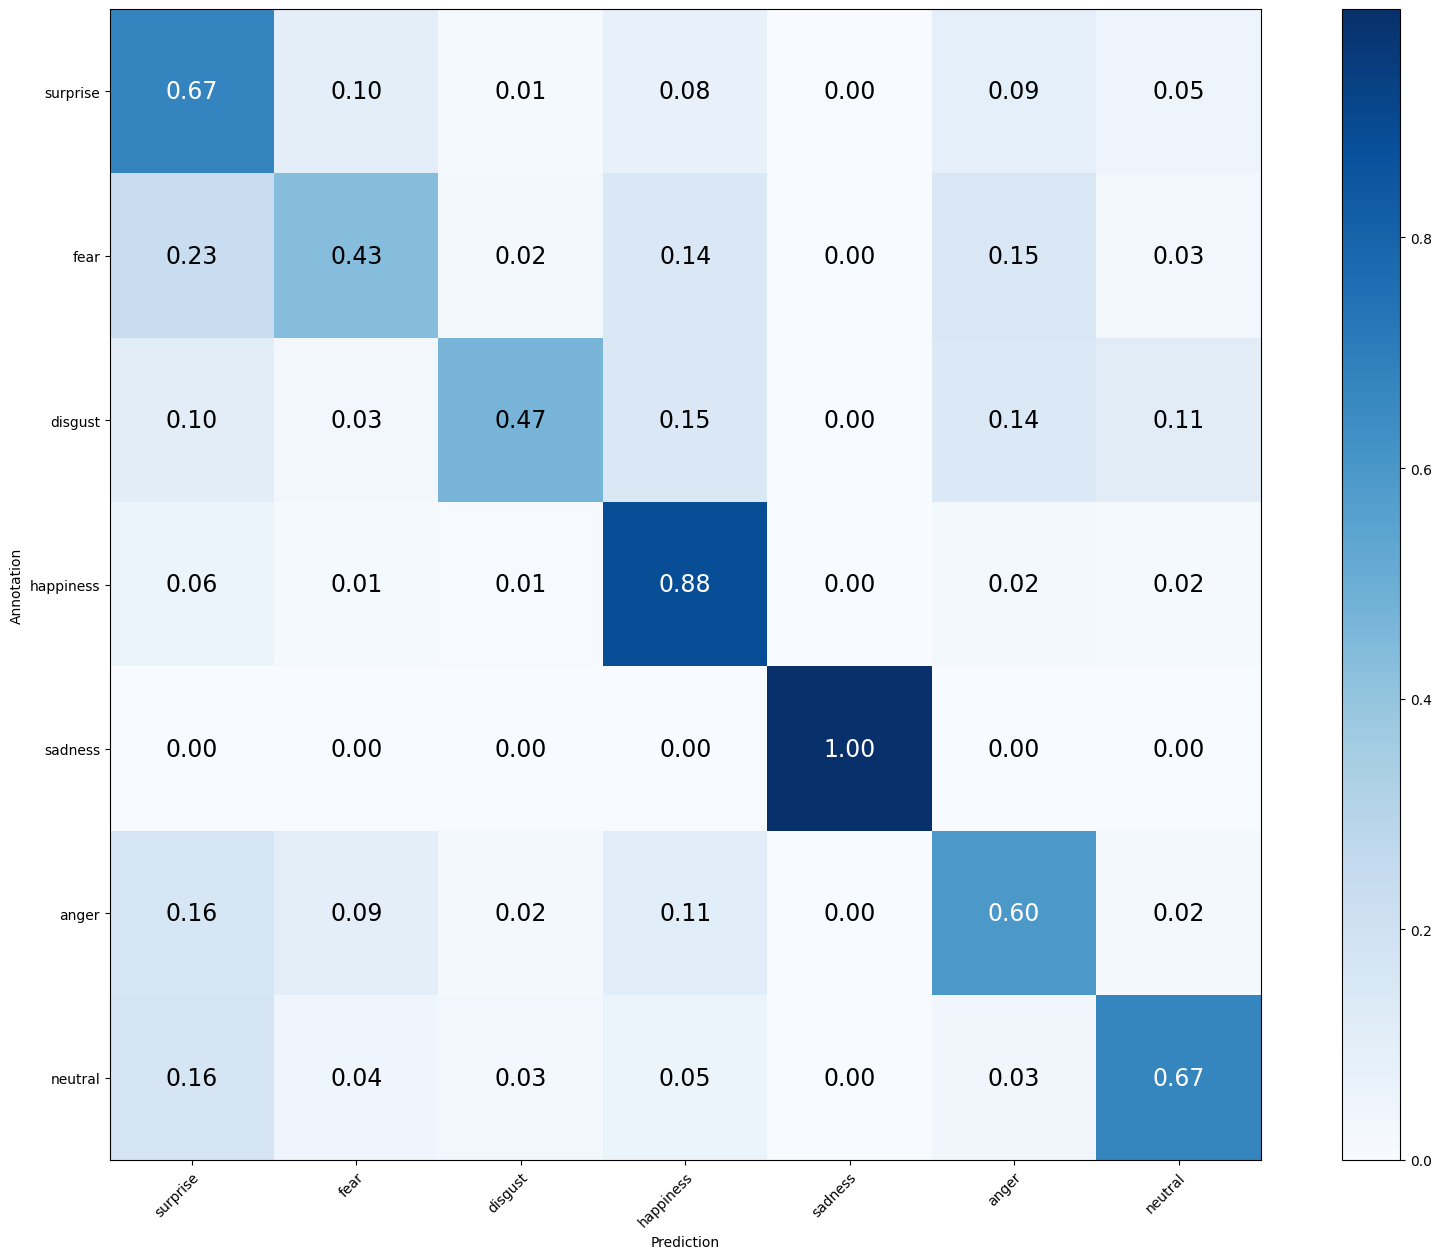

In [129]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show(fig)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.keys()))
draw_confusion_matrix(cm, categories)

In [130]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 79.240%
Mean Recall: 67.454%
Mean Precision: 67.158%
> surprise: Recall: 67.336% Precision: 68.544% Specificity: 92.299% Dice: 67.935%
> fear: Recall: 42.956% Precision: 31.633% Specificity: 95.899% Dice: 36.435%
> disgust: Recall: 47.093% Precision: 44.262% Specificity: 98.986% Dice: 45.634%
> happiness: Recall: 88.353% Precision: 86.370% Specificity: 94.206% Dice: 87.350%
> sadness: Recall: 99.803% Precision: 99.961% Specificity: 99.987% Dice: 99.882%
> anger: Recall: 59.643% Precision: 66.970% Specificity: 95.968% Dice: 63.095%
> neutral: Recall: 66.996% Precision: 72.363% Specificity: 97.804% Dice: 69.576%
